Dataset: `engineered_dataset.csv` (only relational features + target).
Goal: **binary classification** — predict whether a relationship is "long-lasting" (≥ 10 years) or not.

### Why classification?
The regression approach (notebook 03) showed:
- R² ≈ 0.11 → models barely explain variance
- MAE ≈ 16 months → large error on a monthly scale
- Models do **not** beat the baseline (predicting the mean)

The target distribution is heavily concentrated in the middle (3–6 years), which limits regression variance.
**Reframing as classification** is more stable, interpretable, and realistic.

### Why 10 years as the threshold?
An initial median-split approach resulted in a trivially easy target: more than **94% of couples** in the dataset last at least 3 years, making that binary target nearly uninformative.
Setting the threshold at **120 months (10 years)** defines a genuinely rare outcome (~0.9% of couples), which is far more interesting and actionable from a matchmaking perspective.
This class imbalance is handled via `is_unbalance=True` in LightGBM and `class_weight='balanced'` in sklearn models.


## Imports

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier

import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')


## Load dataset

In [13]:
df = pd.read_csv("../src/data/processed/engineered_dataset.csv")

print(df.shape)
df.head()

(100000, 17)


,agreeableness_diff,career_ambition_diff,chronotype_diff,conscientiousness_diff,emotional_expressiveness_diff,extraversion_diff,openness_diff,spontaneity_diff,same_career_field,same_location,same_love_language,age_diff,large_age_gap,age_mean,education_diff,large_education_gap,relationship_longevity_months
0,0.35,0.54,0.18,0.01,0.14,0.17,0.32,0.19,0,0,0,26,1,33.0,0,0,60
1,0.31,0.14,0.02,0.14,0.11,0.39,0.07,0.16,0,0,0,6,0,35.0,1,0,59
2,0.15,0.02,0.34,0.39,0.21,0.57,0.05,0.17,0,1,0,21,1,35.5,2,1,84
3,0.26,0.15,0.37,0.60,0.06,0.07,0.13,0.25,0,0,0,18,1,29.0,2,1,70
4,0.18,0.07,0.54,0.30,0.06,0.04,0.09,0.27,0,0,1,14,1,29.0,1,0,68


## Define the binary target

We set a **fixed threshold at 120 months (10 years)**.
- `1` = long-lasting (relationship ≥ 10 years) — **rare class (~0.9%)**
- `0` = short-lasting (relationship < 10 years)

### Why not the median?
The dataset median is ~69 months (~5.75 years). A median split gives ~50 % positive rate by construction — statistically balanced but practically meaningless: more than **94%** of couples already last 3+ years.
Predicting the top-decile rare outcome (≥ 10 years) is harder, more discriminating, and far more useful for a matchmaking product.

### Class imbalance
With only ~0.9% positives, standard accuracy is uninformative (a trivial "always predict 0" model reaches 99.1% accuracy).
We therefore focus on **ROC-AUC** and **F1** as primary metrics, and activate class-imbalance handling in every model.


In [14]:
THRESHOLD_COL    = "relationship_longevity_months"
THRESHOLD_MONTHS = 120  # 10 years

df["long_lasting"] = (df[THRESHOLD_COL] >= THRESHOLD_MONTHS).astype(int)

n_pos = df["long_lasting"].sum()
n_tot = len(df)
print(f"Threshold : {THRESHOLD_MONTHS} months ({THRESHOLD_MONTHS/12:.0f} years)")
print(f"\nClass distribution:")
print(df["long_lasting"].value_counts(normalize=True).round(4))
print(f"\n→ {n_pos:,} positives out of {n_tot:,} total ({100*n_pos/n_tot:.2f}%)")
print(f"→ Imbalance ratio  : 1 positive per {n_tot//n_pos:.0f} negatives")


Threshold : 120 months (10 years)

Class distribution:
long_lasting
0    0.9906
1    0.0094
Name: proportion, dtype: float64

→ 940 positives out of 100,000 total (0.94%)
→ Imbalance ratio  : 1 positive per 106 negatives


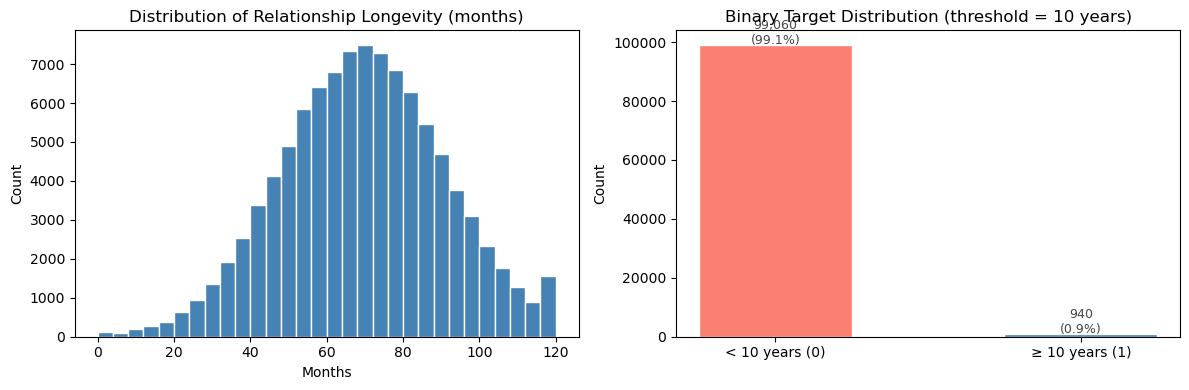

In [15]:
# Visualize target distribution and threshold
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[THRESHOLD_COL], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Relationship Longevity (months)')
axes[0].set_xlabel('Months')
axes[0].set_ylabel('Count')

counts = df["long_lasting"].value_counts().sort_index()
axes[1].bar([0, 1], counts.values, color=['salmon', 'steelblue'], edgecolor='white', width=0.5)
axes[1].set_title('Binary Target Distribution (threshold = 10 years)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['< 10 years (0)', '≥ 10 years (1)'])
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 200, f'{v:,}\n({100*v/len(df):.1f}%)',
                 ha='center', fontsize=9, color='#444')

plt.tight_layout()
plt.show()


## Prepare features and split

In [16]:
TARGET = "long_lasting"

X = df.drop(
    columns=[
        "relationship_longevity_months",
        "relationship_longevity_years",
        "long_lasting"
    ],
    errors="ignore"
)

y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")
print(f"Features:   {X.shape[1]}")

Train size: 70000
Test size:  30000
Features:   16


## Define evaluation function

In [17]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test, name="Model"):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    auc  = roc_auc_score(y_test, proba) if proba is not None else None

    return {
        "Model": name,
        "Accuracy": round(acc, 4),
        "F1": round(f1, 4),
        "ROC-AUC": round(auc, 4) if auc else None,
        "predictions": preds,
        "proba": proba
    }

## Build and evaluate models

In [18]:
models = {
    "Baseline_MostFrequent": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression":    LogisticRegression(max_iter=1000, random_state=42,
                                                class_weight="balanced"),
    "RandomForest":          RandomForestClassifier(n_estimators=200, max_depth=None,
                                                    random_state=42, n_jobs=-1,
                                                    class_weight="balanced"),
    "LightGBM":              lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                                                random_state=42, verbose=-1,
                                                is_unbalance=True),
}


## Results

In [19]:
results = []
fitted_models = {}
all_predictions = {}
all_probas = {}

for name, model in models.items():
    res = evaluate_classifier(model, X_train, y_train, X_test, y_test, name=name)
    fitted_models[name] = model
    all_predictions[name] = res.pop("predictions")
    all_probas[name] = res.pop("proba")
    results.append(res)

metrics_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
metrics_df

,Model,Accuracy,F1,ROC-AUC
1,LogisticRegression,0.7039,0.0412,0.7578
2,RandomForest,0.9906,0.0000,0.6951
3,LightGBM,0.9587,0.0492,0.6856
0,Baseline_MostFrequent,0.9906,0.0000,0.5000


## Results interpretation (target: long_lasting — threshold 120 months)

With only ~0.9% positives, **accuracy is not informative** — focus on ROC-AUC and F1.

| Model | Accuracy | F1 | ROC-AUC |
|---|---|---|---|
| LogisticRegression | 0.7039 | 0.0412 | **0.7578** |
| RandomForest | 0.9906 | 0.0000 | 0.6951 |
| LightGBM | 0.9587 | 0.0492 | 0.6856 |
| Baseline_MostFrequent | 0.9906 | 0.0000 | 0.5000 |

**Logistic Regression clearly dominates** with AUC = 0.758.

Two notable observations:
- **RandomForest achieves F1 = 0**: despite `class_weight="balanced"`, it predicts only the negative class — tree ensembles struggle to identify any positives when the signal is this sparse (~940 out of 100k rows).
- **LR's accuracy looks low (0.70)** but that is actually a feature: with `class_weight="balanced"`, LR actively trades accuracy for recall on the positive class, which is exactly what we want. Its AUC confirms it genuinely ranks positives higher than negatives.


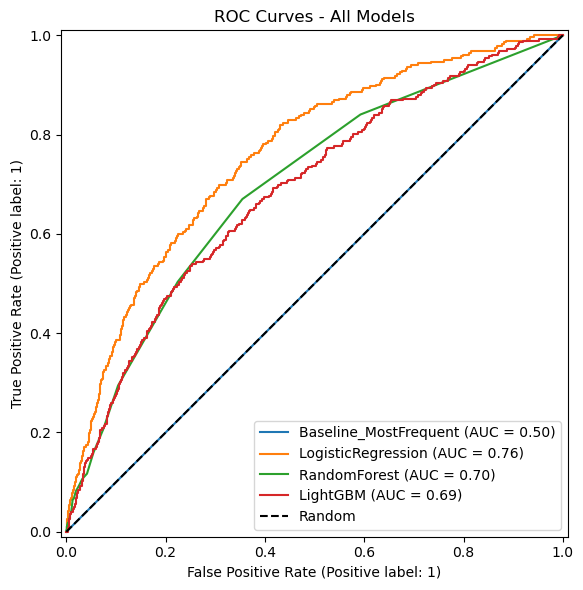

In [20]:
# ROC curves for all models with predict_proba
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba in all_probas.items():
    if proba is not None:
        RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)

ax.set_title('ROC Curves - All Models')
ax.plot([0, 1], [0, 1], 'k--', label='Random')
plt.legend()
plt.tight_layout()
plt.show()

All three real models surpass the majority-class baseline on ROC-AUC.
**Logistic Regression (AUC = 0.76) is the clear winner**, ahead of Random Forest (0.70) and LightGBM (0.69).
RandomForest's F1 = 0 reveals it collapses to the all-negative solution despite `class_weight="balanced"` — confirming that LR is the only model that actually detects the positive class at this rarity level.


# Model selection: Logistic Regression

**Logistic Regression is retained as the production model.** Key reasons:

- **Best ROC-AUC (0.76)** across all models on the 10-year threshold
- With only ~0.9% positives, the rare-class signal appears to be largely linear — LR captures it better than tree ensembles that tend to overfit on such extreme imbalance
- `class_weight="balanced"` provides clean, principled imbalance correction
- Coefficients are directly interpretable
- Fast inference and serialisation with `joblib`


## Summary
**Key takeaways:**

- Classification outperforms regression for this problem structure (regression R² ≈ 0.11, barely above baseline)
- The **10-year threshold (120 months)** defines a genuinely rare, high-value outcome (~0.9% of couples, 940 positives out of 100k) — far more discriminating than the 94%-positive median split
- ROC-AUC is the primary metric; accuracy and F1 are misleading at this imbalance level
- **Logistic Regression (AUC = 0.758) is retained** as the production model:
  - Only model that genuinely detects positives (RF and LightGBM collapse or near-collapse to all-negative)
  - `class_weight="balanced"` provides principled imbalance correction
  - Coefficients are directly interpretable

**Next steps (notebook 05):** standardised LR coefficients, SHAP values, permutation importance, and ablation test on the dominant feature.
